In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

# import magnus
import magnus.magnus as magnus
# import magnus.oscprob.oscprob as oscprob
# import magnus.oscprob.oscprobstd as oscprobstd
# import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
# import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
# import magnus.matter as matter
# import magnus.globaldefs as gd

While the main purpose of Mag$\nu$s is to compute neutrino oscillation probabilities, at its core, it is an efficient implementation of the Magnus expansion of the matrix exponential whose computation is required to compute the time-evolution operator for any given Hamiltonian, including time-dependent (or position-dependent) ones.  Therefore, we can use Mag$\nu$s to compute the Magnus expansion of the matrix exponential
\begin{equation}
 U = \exp\left( \int_{t_i}^{t_f} A(t) dt \right)
\end{equation}
where $A$ is an arbitary $N \times N$ square matrix.  The Magnus expansion of the exponential is
\begin{equation}
 U = \exp\left( \Omega(t_i, t_f) \right) \;,
\end{equation}
where $\Omega$ is the series expansion
\begin{equation}
 \Omega(t_i, t_f) = \sum_{k=1}^{\infty} \Omega_k(t_i, t_f) \;,
\end{equation}
where the terms $\Omega_k$ of the expansion are computed recursively in terms of lower-order terms (see Wikipedia entry).  Mag$\nu$s can return the terms $\Omega_k$ and also the matrix exponential, $U$.  The present version of the code implements calculation up to $k = 6$ term.

First, define a sample $3 \times 3$ complex matrix (unlike the Hamiltonian in the case of neutrino oscillations, it does not have to be Hermitian).

In [3]:
def A3(t):
    # return np.array([[1+1j*t, 2/(1+t), 3j*t], [0, 4-1j*t, 5+3j*t], [-3j*np.sqrt(t), -2j*(1/(1+t)), 1]], dtype=np.complex128)
    return np.array([[1+1j*t, 2*t*2, 3j*t], [0, 4-1j*t, 5+3j*t], [-3j*np.sqrt(t), -2j*t, 1]], dtype=np.complex128)

t_i, t_f = 0, 1 # Initial and final times of the matrix integral

The terms $\Omega_k$ of the expansion have the same dimensions as the input matrix $A_3$ (in this case, $3 \times 3$).  By default, the function `compute_magnus_terms` returns only $\Omega_1$ and $\Omega_2$, and the matrix integral is performed using trapezoidal integration on a grid of 50 points between $t_i$ and $t_f$, evenly spaced in $\log_{10}$ scale.

In [4]:
Omega_1, Omega_2 = magnus.compute_magnus_terms(A3, t_i, t_f) # Each Omega_k returned is a np.ndarray object
print(Omega_1) # The first-order term is just what we would compute were A3 time-independent
print(Omega_2) # The second-order term is the first correction to that

[[1.+0.5j        2.+0.j         0.+1.5j       ]
 [0.+0.j         4.-0.5j        5.+1.5j       ]
 [0.-1.99823381j 0.-1.j         1.+0.j        ]]
[[ 2.13039123e-01+0.00000000e+00j  1.00020825e+00+0.00000000e+00j
   1.66701374e+00+3.39178267e-17j]
 [ 2.13039123e-01+1.00439272e+00j -6.34413157e-17+8.33506872e-01j
  -7.27309369e-16-1.16690962e+00j]
 [-7.10130410e-02+0.00000000e+00j  0.00000000e+00-2.16051959e-01j
  -2.13039123e-01-8.33506872e-01j]]


Now compute terms up to $k = 6$, use a finer grid of 100 points to integrate, and switch from trapezoidal integration to integration via Simpson's rule.

In [141]:
Omega = magnus.compute_magnus_terms(A3, t_i, t_f, n_tpts=100, order=6, integration_method='simpson')
for k, Omega_k in enumerate(Omega):
    print(r'Omega_'+str(k+1)+' = ')
    print(Omega_k)

Omega_1 = 
[[1.+0.5j        2.+0.j         0.+1.5j       ]
 [0.+0.j         4.-0.5j        5.+1.5j       ]
 [0.-1.99975275j 0.-1.j         1.+0.j        ]]
Omega_2 = 
[[ 2.14100232e-01+0.00000000e+00j  1.00000000e+00+0.00000000e+00j
   1.66666667e+00-6.25405778e-17j]
 [ 2.14100232e-01+1.00062475e+00j  2.39239978e-17+8.33333333e-01j
   1.27245763e-15-1.16666667e+00j]
 [-7.13667440e-02+0.00000000e+00j  0.00000000e+00-2.14533024e-01j
  -2.14100232e-01-8.33333333e-01j]]
Omega_3 = 
[[ 0.03240568+0.43676174j  0.01018863+0.43333336j  0.12499999-0.34860854j]
 [ 0.25417758+0.04744315j  0.12685532-0.28613315j  0.40626653-0.04860856j]
 [ 0.22243158-0.04200305j  0.19166668-0.11144085j -0.159261  -0.15062859j]]
Omega_4 = 
[[-0.19621202+0.03916251j -0.17966681+0.46048922j -0.45427233+0.75436515j]
 [-0.87357072-0.09227914j -0.31468476+0.14953313j  0.15482086+0.61269814j]
 [-0.21734167+0.101476j    0.02302895-0.19725914j  0.51089678-0.18869564j]]
Omega_5 = 
[[-0.48176934-0.22679837j -0.21042764-0.0389

To compute the matrix exponential $\exp(\Omega)$, we do not need to compute the Magnus terms separately first.  We can directly call the `magnus_expansion` function, which does it internally.

In [142]:
exp_Omega = magnus.magnus_expansion(A3, t_i, t_f)
print(exp_Omega)

[[ -0.1979577  -32.23340468j  55.50464098 -80.38707373j
   93.20676592 -81.66487421j]
 [-14.26354926 -35.23188203j  24.81675908 -96.59905818j
   65.55103065-110.76753501j]
 [-22.19307777  -1.70015097j -56.74469194 -41.02763939j
  -55.72530347 -66.62235487j]]


And, like before, we can change the order of the expansion, the number of points used in the integration grid, and the integration method.

In [143]:
exp_Omega = magnus.magnus_expansion(A3, t_i, t_f, n_tpts=100, order=6, integration_method='simpson')
print(exp_Omega)

[[  0.44278222 -61.89869951j 105.30418261-112.62096262j
  175.54181024 -91.60373611j]
 [-57.98864443 -75.11563177j  21.35188769-227.24035218j
  125.16431273-266.48388049j]
 [-53.46498387 -10.36197033j -82.40116011-108.1070375j
  -52.65763592-165.40043996j]]


Naturally, the more terms in the Magnus expansion and the finer the integration grid, the more accurate the returned matrix exponential is.  To illustrate this, let's plot the value of the real part of the $U_{11}$ component (i.e., of `exp_Omega[0][0]`) for different choices. 

In [144]:
# Generate the data
n_tpts_min, n_tpts_max = 2, 10
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
exp_Omega_elem_sel = [[magnus.magnus_expansion(A3, t_i, t_f, n_tpts=n, order=o+1, 
                                              integration_method='trapezoid')[elem_sel_i][elem_sel_j].real 
                      for n in range(n_tpts_min, n_tpts_max+1)] for o in range(order_max)]
exp_Omega_elem_sel = np.array(exp_Omega_elem_sel)

Text(0, 0.5, '$\\epsilon_{\\rm rel}$ vs.~$k=6$')

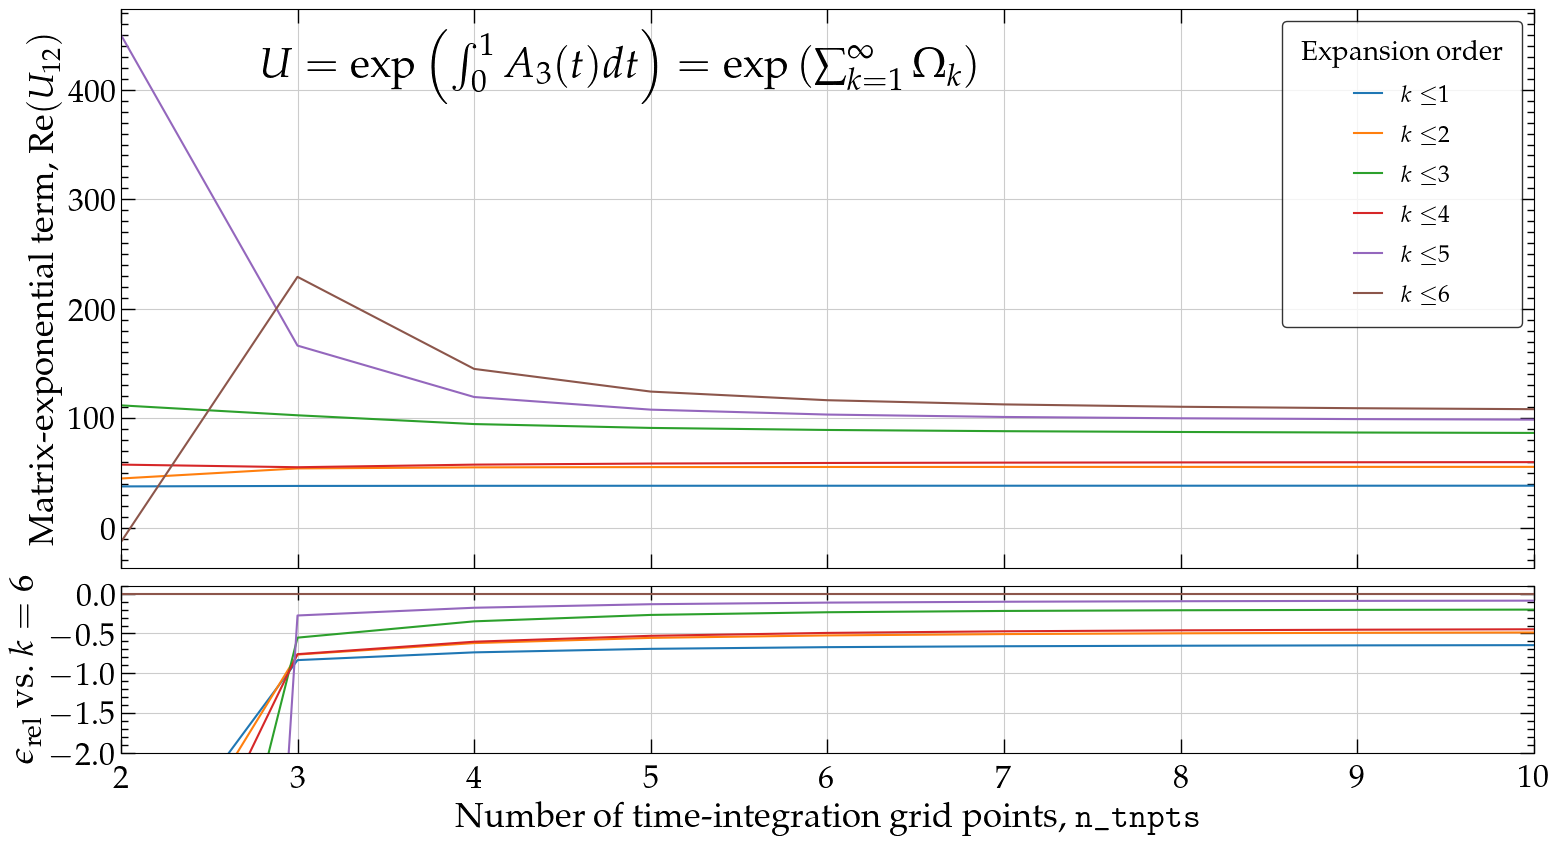

In [150]:
# Open the figure
heights, widths = [1.0, 0.3], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Plot data
n_tpts = range(n_tpts_min, n_tpts_max+1)
for order in range(order_max):
    ax[0].plot(n_tpts, exp_Omega_elem_sel[order], label='$k \leq $'+str(order+1))
    rel_error = (exp_Omega_elem_sel[order]-exp_Omega_elem_sel[order_max-1])/exp_Omega_elem_sel[order_max-1]
    ax[1].plot(n_tpts, rel_error)

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Expansion order')

# Annotate
ax[0].annotate(r'$U = \exp \left( \int_0^1 A_3(t) dt \right) = \exp \left( \sum_{k=1}^\infty \Omega_k \right) $', 
               xy = (0.10, 0.88),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(n_tpts_min, n_tpts_max)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
ax[1].set_ylim(-2, 0.1)
ax[0].xaxis.set_ticklabels([])
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=100))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=10))
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.5))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.1))
ax[0].set_ylabel(r'Matrix-exponential term, ${\rm Re} (U_{12})$')
ax[1].set_xlabel(r'Number of time-integration grid points, \texttt{n_tnpts}')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}$ vs.~$k=6$')

# Save plot
# filename = 'magnus_expansion_performance_vs_n_tnpts'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

This shows that, at least for short time intervals, like $t_i = 0$ to $t_f = 1$, it is enough to sue `n_tnpts = 10` points in the integration grid, and expansion up to $k = 6$.

However, because the Magnus expansion involves calculating exponential, it can result in an overflow if its argument is too large, i.e., if $t_f - t_f \gg 1$.  In this case, we partition the interval $[t_i, t_f]$ into multiple, smaller subintervals, compute the matrix exponential in each via Magnus expansion, and then compute their time-ordered product.  (This is actually the strategy adopted by Mag$\nu$s to compute neutrino oscillation probabilities.)

order = 1
order = 2
order = 3
order = 4
order = 5
order = 6


Text(0, 0.5, '$\\epsilon_{\\rm rel}$ vs. best')

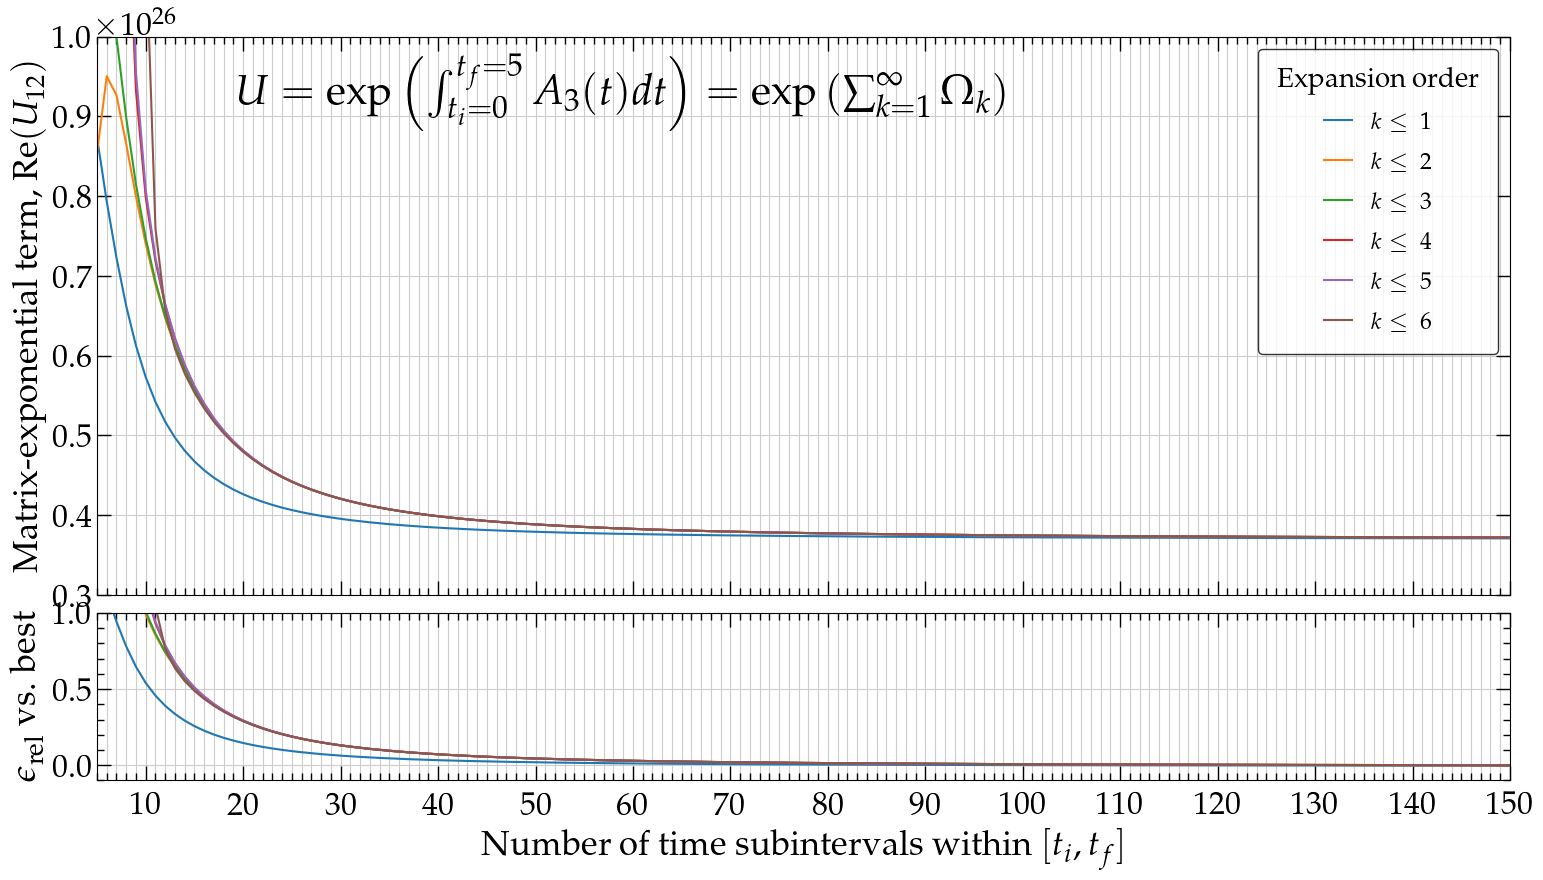

In [22]:
# Set run parameters
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
t_i, t_f = 0, 5
n_subintervals_min, n_subintervals_max = 5, 150

# Open the figure
heights, widths = [1.0, 0.3], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Compute the best case, to compare all others against
dt = (t_f-t_i)/n_subintervals_max # Width of each time subinterval
subintervals = np.array([[dt*i, dt*(i+1)] for i in range(n_subintervals_max)]) # Start and stop of each ubinterval
# Compute the matrix exponential in each subinterval
exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, subint[0], subint[1], n_tpts=10, order=order_max, 
                                                      integration_method='trapezoid') for subint in subintervals])
# Compute the time-ordered product of the matrix exponentials and save the selected matrix component
best = abs(np.linalg.multi_dot(exp_Omega_subintervals)[elem_sel_i][elem_sel_j].real)

# Now compute all other cases and plot them
for order in range(order_max):
    print("order = "+str(order+1))
    # Generate the data
    exp_Omega_elem_sel = []
    for n_subintervals in range(n_subintervals_min, n_subintervals_max+1): # Number of time subintervals into which we divide [t_i, t_f]
        # print(n_subintervals)
        dt = (t_f-t_i)/n_subintervals # Width of each time subinterval
        subintervals = np.array([[dt*i, dt*(i+1)] for i in range(n_subintervals)]) # Start and stop of each ubinterval
        # Compute the matrix exponential in each subinterval
        exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, subint[0], subint[1], n_tpts=10, order=order+1, 
                                                      integration_method='trapezoid') for subint in subintervals])
        # Compute the time-ordered product of the matrix exponentials and save the selected matrix component
        exp_Omega_elem_sel.append(abs(np.linalg.multi_dot(exp_Omega_subintervals)[elem_sel_i][elem_sel_j].real))
    # Plot the data
    ax[0].plot(range(n_subintervals_min, n_subintervals_max+1), exp_Omega_elem_sel, label='$k \leq~$'+str(order+1))
    rel_error = (exp_Omega_elem_sel-best)/best
    ax[1].plot(range(n_subintervals_min, n_subintervals_max+1), rel_error)

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Expansion order')

# Annotate
ax[0].annotate(r'$U = \exp \left( \int_{t_i=0}^{t_f=5} A_3(t) dt \right) = \exp \left( \sum_{k=1}^\infty \Omega_k \right) $', 
               xy = (0.10, 0.88),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(n_subintervals_min, n_subintervals_max)
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
# ax[0].set_yscale('log')
ax[0].set_ylim(3.e25, 1.e26)
ax[1].set_ylim(-0.1, 1)
ax[0].xaxis.set_ticklabels([])
# ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=100))
# ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=10))
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.5))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.1))
ax[0].set_ylabel(r'Matrix-exponential term, ${\rm Re} (U_{12})$')
ax[1].set_xlabel(r'Number of time subintervals within $[t_i, t_f]$')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}$ vs. best')

# Save plot
# filename = 'magnus_expansion_performance_vs_n_subintervals'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

So, in this case, about 100 subintervals are enough, regardless of the order of the Magnus expansion used.  This is because if there are many subintervals, then the corrections of higher-order terms within each subinterval are small.

Finally, let's see how this changes when we widen the interval $[t_i, t_f]$.

  n_subintervals = 3
  order = 1
  order = 2
  order = 3
  order = 4
  order = 5
  order = 6
  n_subintervals = 10
  order = 1
  order = 2
  order = 3
  order = 4
  order = 5
  order = 6
  n_subintervals = 100
  order = 1
  order = 2
  order = 3
  order = 4
  order = 5
  order = 6


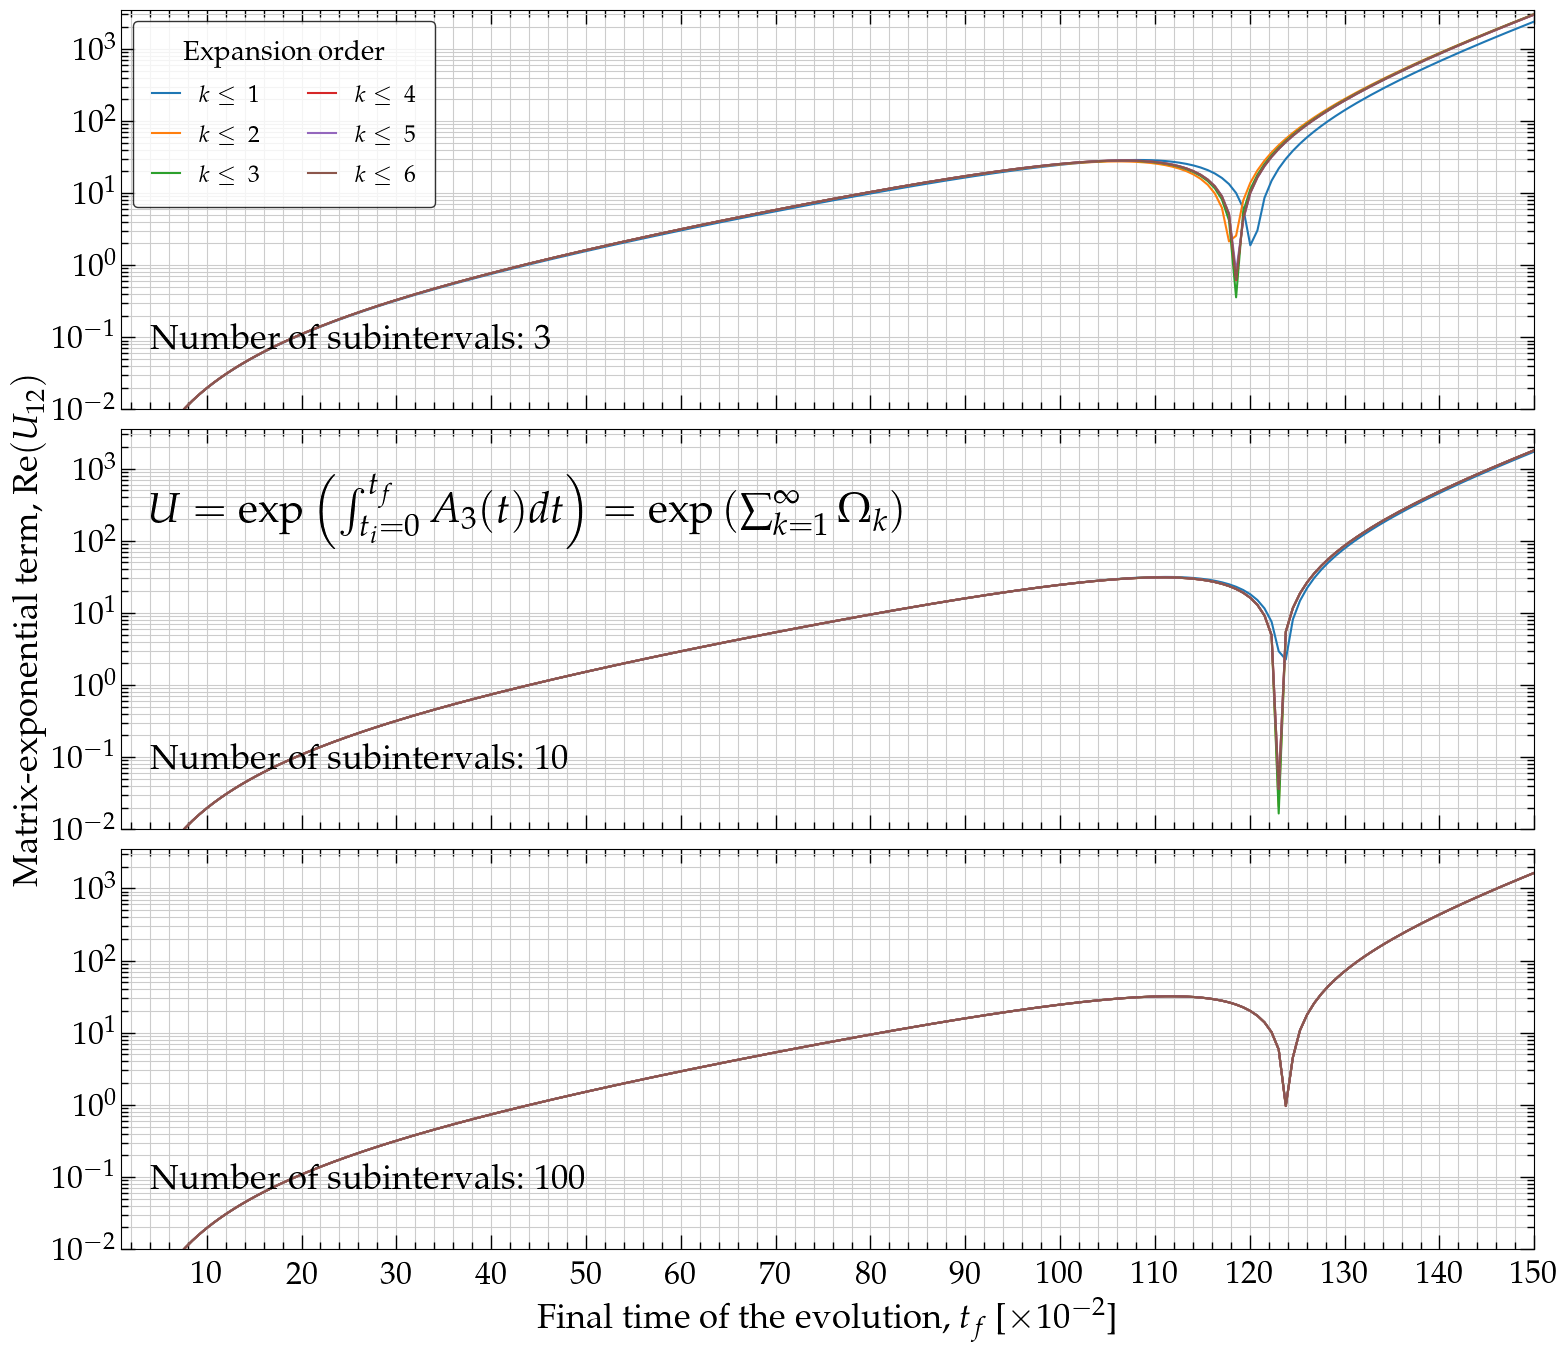

In [86]:
# Set run parameters
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
t_i = 1
t_f_max = 150
t_f_arr = np.linspace(t_i, t_f_max, 200)
t_modifier = 1.e-2

# Open the figure
heights, widths = [1.0, 1.0, 1.0], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=3, 
    gridspec_kw=gs_kw, 
    figsize=[18,15])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

n_subintervals_arr = [3,10,100]
for i, axx in enumerate(ax):
    n_subintervals = n_subintervals_arr[i]
    print("  n_subintervals = "+str(n_subintervals))
    for order in range(order_max):
        print("  order = "+str(order+1))
        # Generate the data
        exp_Omega_elem_sel = []
        for t_f in t_f_arr:
            dt = (t_f-t_i)/n_subintervals # Width of each time subinterval
            subintervals = np.array([[dt*i, dt*(i+1)] for i in range(n_subintervals)]) # Start and stop of each ubinterval
            # Compute the matrix exponential in each subinterval
            exp_Omega_subintervals = np.array([magnus.magnus_expansion(A3, t_modifier*subint[0], t_modifier*subint[1], 
                                                                       n_tpts=10, order=order+1, integration_method='trapezoid') 
                                               for subint in subintervals])
            # Compute the time-ordered product of the matrix exponentials and save the selected matrix component
            exp_Omega_elem_sel.append(abs(np.linalg.multi_dot(exp_Omega_subintervals)[elem_sel_i][elem_sel_j].real))
        # Plot the data
        axx.plot(t_f_arr, exp_Omega_elem_sel, label='$k \leq~$'+str(order+1))

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=2, title=r'Expansion order')

# Annotate
ax[1].annotate(r'$U = \exp \left( \int_{t_i=0}^{t_f} A_3(t) dt \right) = \exp \left( \sum_{k=1}^\infty \Omega_k \right) $', 
               xy = (0.02, 0.77),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(t_f_arr[0], t_f_arr[-1])
    axx.set_ylim(1.e-2, 3500)
    axx.set_yscale('log')
    axx.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    axx.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=2))
    # axx.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=5))
    # axx.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='both', axis='y')
    if (i != 2):
        axx.xaxis.set_ticklabels([])
    else:
        axx.set_xlabel(r'Final time of the evolution, $t_f$ [$\times 10^{-2}$]')
    if (i == 1):
        axx.set_ylabel(r'Matrix-exponential term, ${\rm Re} (U_{12})$')
    axx.annotate(r'Number of subintervals: '+str(n_subintervals_arr[i]), 
                 xy = (0.02, 0.15),  xycoords='axes fraction',  ha='left', fontsize=25)

# Save plot
# filename = 'magnus_expansion_performance_vs_t_f'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

This shows that, as expected, the most accurate results are obtained using a high-order expansion and a large number of subintervals.  However, there is a trade-off between accuracy and speed.  The decision whether to favor one or the other, and to what extent will depend on the specific problem at hand.